# Healthcare Provider Fraud Detection - Model Evaluation & Business Impact

## Objective
This notebook provides a comprehensive evaluation of the fraud detection model, including:
- **Threshold Optimization**: Finding the optimal decision boundary
- **Cost-Benefit Analysis**: Understanding the financial implications
- **Error Analysis**: Deep dive into model mistakes and patterns
- **Business Impact Assessment**: Translating model performance to business value
- **Final Recommendations**: Actionable insights for deployment

**Context**: Healthcare fraud costs over $68 billion annually. Our goal is to maximize fraud detection while minimizing false accusations.

## 1. Import Libraries and Load Model

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model loading
import pickle

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Saved Model and Data

We'll load the trained XGBoost model and test data from the modeling phase.

In [6]:
# Check if we're in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab environment")
except:
    IN_COLAB = False
    print("Running in local environment")

Running in Google Colab environment


In [7]:
# Load the trained model
model_path = '/content/final_fraud_detection_model.pkl' if IN_COLAB else 'final_fraud_detection_model.pkl'
scaler_path = '/content/scaler.pkl' if IN_COLAB else 'scaler.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)

with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print("✓ Model and scaler loaded successfully")
print(f"Model type: {type(model).__name__}")

✓ Model and scaler loaded successfully
Model type: XGBClassifier


In [8]:
# Load the dataset
file_path = '/content/01_X_y_for_modeling.csv' if IN_COLAB else '01_X_y_for_modeling.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['PotentialFraud'].mean()*100:.2f}%")

# Separate features and target
X = df.drop('PotentialFraud', axis=1)
y = df['PotentialFraud']

print(f"\nFeatures: {X.shape[1]}")
print(f"Total providers: {len(y)}")
print(f"Fraudulent providers: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")

Dataset shape: (5410, 25)
Fraud rate: 9.35%

Features: 24
Total providers: 5410
Fraudulent providers: 506 (9.4%)


In [9]:
# Recreate the train/test split used in modeling
from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Scale the test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Test set size: {len(y_test)} providers")
print(f"Test set fraud rate: {y_test.sum()/len(y_test)*100:.1f}%")

Test set size: 1082 providers
Test set fraud rate: 9.3%


In [10]:
# Generate predictions on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions generated")
print(f"Predicted fraudulent: {y_pred.sum()} ({y_pred.sum()/len(y_pred)*100:.1f}%)")
print(f"Average fraud probability: {y_pred_proba.mean():.3f}")

✓ Predictions generated
Predicted fraudulent: 106 (9.8%)
Average fraud probability: 0.110


## 3. Baseline Performance Summary

Review the model's performance with the default 0.5 threshold.

In [11]:
def print_metrics(y_true, y_pred, y_pred_proba, title="Model Performance"):
    """
    Print comprehensive metrics for model evaluation.
    """
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}\n")

    # Calculate metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)

    print(f"Precision:  {precision:.4f}  (Of flagged providers, {precision*100:.1f}% are actually fraudulent)")
    print(f"Recall:     {recall:.4f}  (We catch {recall*100:.1f}% of all fraudsters)")
    print(f"F1-Score:   {f1:.4f}  (Harmonic mean of Precision and Recall)")
    print(f"ROC-AUC:    {roc_auc:.4f}  (Overall discriminative ability)")
    print(f"PR-AUC:     {pr_auc:.4f}  (Performance on minority class)")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion Matrix:")
    print(f"  True Negatives (TN):  {tn:4d} - Correctly identified legitimate providers")
    print(f"  False Positives (FP): {fp:4d} - Legitimate providers wrongly flagged (⚠️ wastes resources)")
    print(f"  False Negatives (FN): {fn:4d} - Fraudsters we MISSED (⚠️⚠️ critical!)")
    print(f"  True Positives (TP):  {tp:4d} - Correctly identified fraudsters")

    return {'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

# Print baseline metrics
baseline_metrics = print_metrics(y_test, y_pred, y_pred_proba, "Baseline Performance (Threshold = 0.5)")


  Baseline Performance (Threshold = 0.5)

Precision:  0.6604  (Of flagged providers, 66.0% are actually fraudulent)
Recall:     0.6931  (We catch 69.3% of all fraudsters)
F1-Score:   0.6763  (Harmonic mean of Precision and Recall)
ROC-AUC:    0.9629  (Overall discriminative ability)
PR-AUC:     0.7388  (Performance on minority class)

Confusion Matrix:
  True Negatives (TN):   945 - Correctly identified legitimate providers
  False Positives (FP):   36 - Legitimate providers wrongly flagged (⚠️ wastes resources)
  False Negatives (FN):   31 - Fraudsters we MISSED (⚠️⚠️ critical!)
  True Positives (TP):    70 - Correctly identified fraudsters


## 4. Threshold Optimization

The default classification threshold is 0.5, but this may not be optimal for fraud detection.

**Key Trade-off:**
- **Lower threshold** → More fraud detected (higher recall) but more false alarms (lower precision)
- **Higher threshold** → Fewer false alarms (higher precision) but miss more fraud (lower recall)

We'll analyze different thresholds to find the optimal balance.

In [12]:
# Calculate metrics for different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)

    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()

    metrics_by_threshold.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

threshold_df = pd.DataFrame(metrics_by_threshold)
print("Threshold Analysis:")
print(threshold_df[['threshold', 'precision', 'recall', 'f1', 'tp', 'fp', 'fn']].round(3))

Threshold Analysis:
    threshold  precision  recall     f1  tp  fp  fn
0        0.10      0.473   0.881  0.616  89  99  12
1        0.15      0.503   0.851  0.632  86  85  15
2        0.20      0.523   0.792  0.630  80  73  21
3        0.25      0.528   0.752  0.620  76  68  25
4        0.30      0.562   0.713  0.629  72  56  29
5        0.35      0.590   0.713  0.646  72  50  29
6        0.40      0.615   0.713  0.661  72  45  29
7        0.45      0.636   0.693  0.664  70  40  31
8        0.50      0.660   0.693  0.676  70  36  31
9        0.55      0.693   0.693  0.693  70  31  31
10       0.60      0.684   0.663  0.673  67  31  34
11       0.65      0.703   0.634  0.667  64  27  37
12       0.70      0.713   0.614  0.660  62  25  39
13       0.75      0.738   0.584  0.652  59  21  42
14       0.80      0.784   0.574  0.663  58  16  43
15       0.85      0.821   0.545  0.655  55  12  46


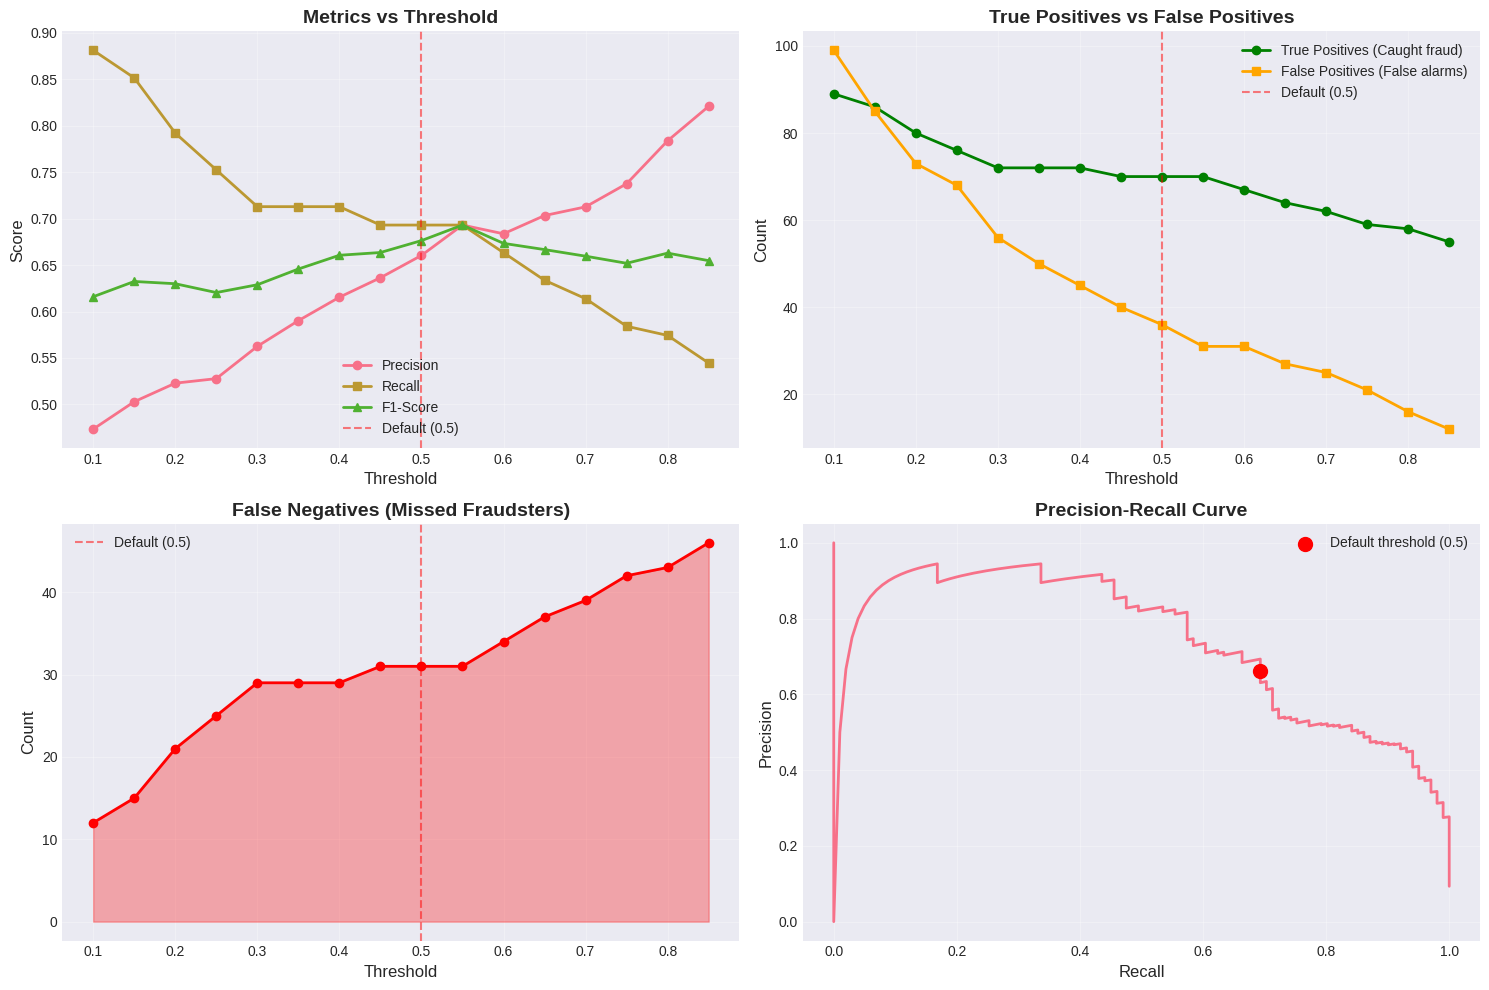

In [13]:
# Visualize threshold impact
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Precision vs Recall vs F1
axes[0, 0].plot(threshold_df['threshold'], threshold_df['precision'], 'o-', label='Precision', linewidth=2)
axes[0, 0].plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', linewidth=2)
axes[0, 0].plot(threshold_df['threshold'], threshold_df['f1'], '^-', label='F1-Score', linewidth=2)
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0, 0].set_xlabel('Threshold', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(alpha=0.3)

# Plot 2: True Positives vs False Positives
axes[0, 1].plot(threshold_df['threshold'], threshold_df['tp'], 'o-', label='True Positives (Caught fraud)',
                color='green', linewidth=2)
axes[0, 1].plot(threshold_df['threshold'], threshold_df['fp'], 's-', label='False Positives (False alarms)',
                color='orange', linewidth=2)
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0, 1].set_xlabel('Threshold', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('True Positives vs False Positives', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Plot 3: False Negatives
axes[1, 0].plot(threshold_df['threshold'], threshold_df['fn'], 'o-', color='red', linewidth=2)
axes[1, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1, 0].set_xlabel('Threshold', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('False Negatives (Missed Fraudsters)', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].fill_between(threshold_df['threshold'], threshold_df['fn'], alpha=0.3, color='red')

# Plot 4: Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 1].plot(recall_curve, precision_curve, linewidth=2)
axes[1, 1].scatter([baseline_metrics['recall']], [baseline_metrics['precision']],
                   color='red', s=100, zorder=5, label=f'Default threshold (0.5)')
axes[1, 1].set_xlabel('Recall', fontsize=12)
axes[1, 1].set_ylabel('Precision', fontsize=12)
axes[1, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Find optimal thresholds based on different criteria
optimal_f1_idx = threshold_df['f1'].idxmax()
optimal_f1_thresh = threshold_df.loc[optimal_f1_idx, 'threshold']

# Find threshold that maximizes recall while maintaining precision >= 0.6
high_precision_df = threshold_df[threshold_df['precision'] >= 0.6]
if len(high_precision_df) > 0:
    optimal_recall_idx = high_precision_df['recall'].idxmax()
    optimal_recall_thresh = high_precision_df.loc[optimal_recall_idx, 'threshold']
else:
    optimal_recall_thresh = 0.5

print("\n" + "="*70)
print("  OPTIMAL THRESHOLDS")
print("="*70)
print(f"\n1. Maximum F1-Score:")
print(f"   Threshold: {optimal_f1_thresh:.2f}")
print(f"   Precision: {threshold_df.loc[optimal_f1_idx, 'precision']:.3f}")
print(f"   Recall:    {threshold_df.loc[optimal_f1_idx, 'recall']:.3f}")
print(f"   F1-Score:  {threshold_df.loc[optimal_f1_idx, 'f1']:.3f}")

if len(high_precision_df) > 0:
    print(f"\n2. Best Recall with Precision ≥ 0.6:")
    print(f"   Threshold: {optimal_recall_thresh:.2f}")
    print(f"   Precision: {high_precision_df.loc[optimal_recall_idx, 'precision']:.3f}")
    print(f"   Recall:    {high_precision_df.loc[optimal_recall_idx, 'recall']:.3f}")
    print(f"   F1-Score:  {high_precision_df.loc[optimal_recall_idx, 'f1']:.3f}")


  OPTIMAL THRESHOLDS

1. Maximum F1-Score:
   Threshold: 0.55
   Precision: 0.693
   Recall:    0.693
   F1-Score:  0.693

2. Best Recall with Precision ≥ 0.6:
   Threshold: 0.40
   Precision: 0.615
   Recall:    0.713
   F1-Score:  0.661


## 5. Cost-Benefit Analysis

Translate model performance into financial impact.

**Assumptions** (based on industry estimates):
- Average fraudulent claim amount: **$25,000** per provider per year
- Cost of investigating a flagged provider: **$5,000**
- Cost of missing a fraudster: **$25,000** (continued fraud)

**Cost Calculation:**
- **True Positive (TP)**: Investigation cost - Fraud prevented = -$5,000 + $25,000 = **$20,000 saved**
- **False Positive (FP)**: Investigation cost = **-$5,000 lost**
- **True Negative (TN)**: No cost = **$0**
- **False Negative (FN)**: Fraud continues = **-$25,000 lost**

In [15]:
# Define cost parameters
FRAUD_COST = 25000  # Average fraud amount per provider
INVESTIGATION_COST = 5000  # Cost to investigate a flagged provider
TP_VALUE = FRAUD_COST - INVESTIGATION_COST  # Savings from catching fraud
FP_COST = -INVESTIGATION_COST  # Cost of false alarm
FN_COST = -FRAUD_COST  # Cost of missing fraud
TN_VALUE = 0  # No cost for correct negatives

print("Cost-Benefit Parameters:")
print(f"  Fraud amount per provider:        ${FRAUD_COST:,}")
print(f"  Investigation cost per provider:  ${INVESTIGATION_COST:,}")
print(f"  True Positive value:              ${TP_VALUE:,} (fraud prevented - investigation cost)")
print(f"  False Positive cost:              ${FP_COST:,} (wasted investigation)")
print(f"  False Negative cost:              ${FN_COST:,} (missed fraud)")
print(f"  True Negative value:              ${TN_VALUE:,} (no action needed)")

Cost-Benefit Parameters:
  Fraud amount per provider:        $25,000
  Investigation cost per provider:  $5,000
  True Positive value:              $20,000 (fraud prevented - investigation cost)
  False Positive cost:              $-5,000 (wasted investigation)
  False Negative cost:              $-25,000 (missed fraud)
  True Negative value:              $0 (no action needed)


In [16]:
def calculate_financial_impact(tp, fp, tn, fn):
    """
    Calculate total financial impact based on confusion matrix.
    """
    tp_value = tp * TP_VALUE
    fp_value = fp * FP_COST
    tn_value = tn * TN_VALUE
    fn_value = fn * FN_COST

    total_value = tp_value + fp_value + tn_value + fn_value

    return {
        'tp_value': tp_value,
        'fp_value': fp_value,
        'tn_value': tn_value,
        'fn_value': fn_value,
        'total_value': total_value
    }

# Calculate baseline financial impact
baseline_impact = calculate_financial_impact(
    baseline_metrics['tp'],
    baseline_metrics['fp'],
    baseline_metrics['tn'],
    baseline_metrics['fn']
)

print("\n" + "="*70)
print("  FINANCIAL IMPACT - Baseline Model (Threshold = 0.5)")
print("="*70)
print(f"\nValue from True Positives:   ${baseline_impact['tp_value']:>12,} (caught {baseline_metrics['tp']} fraudsters)")
print(f"Cost from False Positives:   ${baseline_impact['fp_value']:>12,} (investigated {baseline_metrics['fp']} legitimate providers)")
print(f"Cost from False Negatives:   ${baseline_impact['fn_value']:>12,} (missed {baseline_metrics['fn']} fraudsters)")
print(f"Value from True Negatives:   ${baseline_impact['tn_value']:>12,} (no cost)")
print(f"\n{'─'*70}")
print(f"TOTAL NET VALUE:             ${baseline_impact['total_value']:>12,}")
print(f"{'─'*70}")

# Compare to no-model scenario
total_fraud_cost_no_model = y_test.sum() * FRAUD_COST
print(f"\nWithout model (all fraud goes undetected): ${-total_fraud_cost_no_model:,}")
print(f"With model:                                 ${baseline_impact['total_value']:,}")
print(f"Model value:                                ${baseline_impact['total_value'] + total_fraud_cost_no_model:,}")


  FINANCIAL IMPACT - Baseline Model (Threshold = 0.5)

Value from True Positives:   $   1,400,000 (caught 70 fraudsters)
Cost from False Positives:   $    -180,000 (investigated 36 legitimate providers)
Cost from False Negatives:   $    -775,000 (missed 31 fraudsters)
Value from True Negatives:   $           0 (no cost)

──────────────────────────────────────────────────────────────────────
TOTAL NET VALUE:             $     445,000
──────────────────────────────────────────────────────────────────────

Without model (all fraud goes undetected): $-2,525,000
With model:                                 $445,000
Model value:                                $2,970,000


In [17]:
# Calculate financial impact for all thresholds
threshold_df['total_value'] = threshold_df.apply(
    lambda row: calculate_financial_impact(row['tp'], row['fp'], row['tn'], row['fn'])['total_value'],
    axis=1
)

# Find threshold with maximum financial value
optimal_value_idx = threshold_df['total_value'].idxmax()
optimal_value_thresh = threshold_df.loc[optimal_value_idx, 'threshold']
optimal_value = threshold_df.loc[optimal_value_idx, 'total_value']

print("\n" + "="*70)
print("  OPTIMAL THRESHOLD - Maximum Financial Value")
print("="*70)
print(f"\nOptimal threshold:  {optimal_value_thresh:.2f}")
print(f"Precision:          {threshold_df.loc[optimal_value_idx, 'precision']:.3f}")
print(f"Recall:             {threshold_df.loc[optimal_value_idx, 'recall']:.3f}")
print(f"F1-Score:           {threshold_df.loc[optimal_value_idx, 'f1']:.3f}")
print(f"\nTrue Positives:     {threshold_df.loc[optimal_value_idx, 'tp']:.0f}")
print(f"False Positives:    {threshold_df.loc[optimal_value_idx, 'fp']:.0f}")
print(f"False Negatives:    {threshold_df.loc[optimal_value_idx, 'fn']:.0f}")
print(f"\nTotal Net Value:    ${optimal_value:,.0f}")


  OPTIMAL THRESHOLD - Maximum Financial Value

Optimal threshold:  0.10
Precision:          0.473
Recall:             0.881
F1-Score:           0.616

True Positives:     89
False Positives:    99
False Negatives:    12

Total Net Value:    $985,000


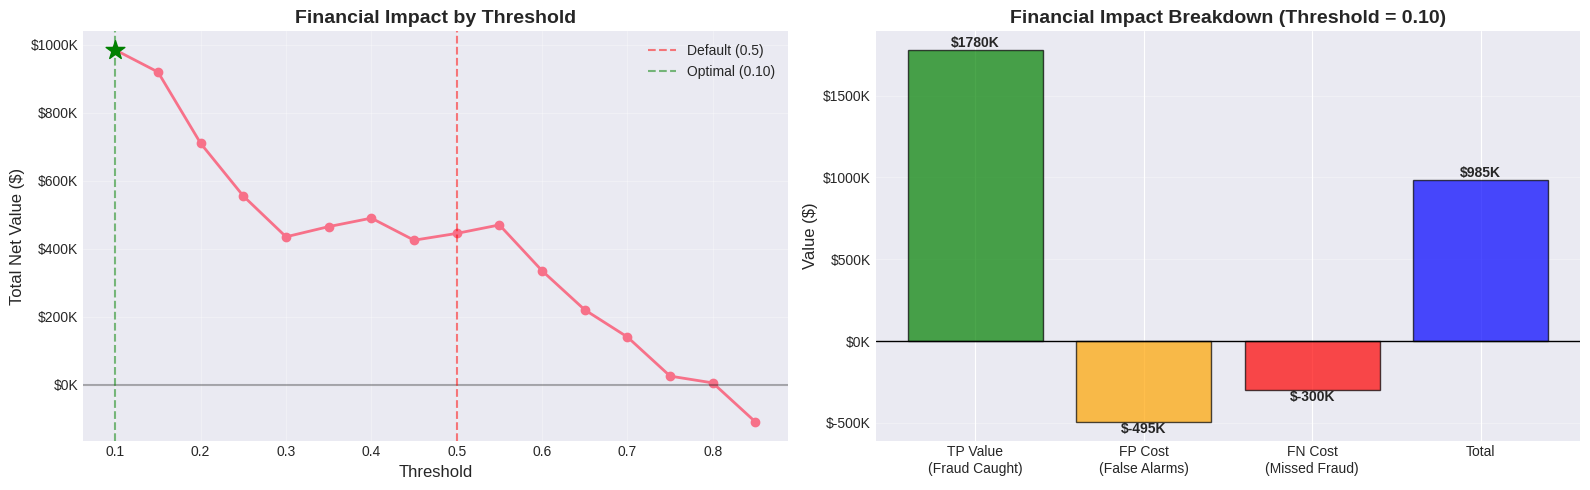


💡 Insight: Using threshold 0.10 maximizes financial value at $985,000


In [18]:
# Visualize financial impact across thresholds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total financial value by threshold
axes[0].plot(threshold_df['threshold'], threshold_df['total_value'], 'o-', linewidth=2, markersize=6)
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].axvline(x=optimal_value_thresh, color='green', linestyle='--', alpha=0.5,
                label=f'Optimal ({optimal_value_thresh:.2f})')
axes[0].scatter([optimal_value_thresh], [optimal_value], color='green', s=200, zorder=5, marker='*')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Total Net Value ($)', fontsize=12)
axes[0].set_title('Financial Impact by Threshold', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: Component breakdown at optimal threshold
optimal_impact = calculate_financial_impact(
    threshold_df.loc[optimal_value_idx, 'tp'],
    threshold_df.loc[optimal_value_idx, 'fp'],
    threshold_df.loc[optimal_value_idx, 'tn'],
    threshold_df.loc[optimal_value_idx, 'fn']
)

components = ['TP Value\n(Fraud Caught)', 'FP Cost\n(False Alarms)', 'FN Cost\n(Missed Fraud)', 'Total']
values = [
    optimal_impact['tp_value'],
    optimal_impact['fp_value'],
    optimal_impact['fn_value'],
    optimal_impact['total_value']
]
colors = ['green', 'orange', 'red', 'blue']

bars = axes[1].bar(components, values, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_ylabel('Value ($)', fontsize=12)
axes[1].set_title(f'Financial Impact Breakdown (Threshold = {optimal_value_thresh:.2f})',
                  fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'${value/1000:.0f}K',
                ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: Using threshold {optimal_value_thresh:.2f} maximizes financial value at ${optimal_value:,.0f}")

## 6. Detailed Error Analysis

Examine specific cases where the model fails to understand limitations and opportunities for improvement.

In [19]:
# Use optimal threshold for error analysis
y_pred_optimal = (y_pred_proba >= optimal_value_thresh).astype(int)

# Identify error cases
false_positives = np.where((y_test.values == 0) & (y_pred_optimal == 1))[0]
false_negatives = np.where((y_test.values == 1) & (y_pred_optimal == 0))[0]

print(f"Error Analysis at Optimal Threshold ({optimal_value_thresh:.2f}):")
print(f"  False Positives: {len(false_positives)}")
print(f"  False Negatives: {len(false_negatives)}")

Error Analysis at Optimal Threshold (0.10):
  False Positives: 99
  False Negatives: 12


In [20]:
# Analyze False Positives - Why did we flag these legitimate providers?
print("\n" + "="*80)
print("FALSE POSITIVE ANALYSIS - Legitimate Providers Wrongly Flagged")
print("="*80)

num_cases = min(3, len(false_positives))
for i in range(num_cases):
    idx = false_positives[i]

    print(f"\n{'─'*80}")
    print(f"Case {i+1}:")
    print(f"  Actual: Legitimate (0)")
    print(f"  Predicted: Fraudulent (1)")
    print(f"  Fraud Probability: {y_pred_proba[idx]:.3f}")
    print(f"\nTop 5 Feature Values (Scaled):")

    # Get feature values
    features = X_test_scaled.iloc[idx]
    top_features = features.abs().nlargest(5)

    for feat_name in top_features.index:
        print(f"  {feat_name:30s}: {features[feat_name]:>8.3f}")

    print(f"\n  💡 Possible Reason:")
    # Analyze based on feature values
    if features['Inp_TotalCost'] > 1.5:
        print("     - High inpatient costs flagged as suspicious")
    if features['Inp_AvgLengthOfStay'] > 1.0:
        print("     - Long hospital stays triggered alert")
    if features['AvgCost_PerClaim'] > 1.0:
        print("     - High average claim costs appeared abnormal")
    if features['Total_Claims'] > 1.5:
        print("     - High claim volume raised suspicion")

    print("\n  🔍 Investigation Priority: Low-Medium")
    print("     (May be high-cost specialty provider, not fraud)")


FALSE POSITIVE ANALYSIS - Legitimate Providers Wrongly Flagged

────────────────────────────────────────────────────────────────────────────────
Case 1:
  Actual: Legitimate (0)
  Predicted: Fraudulent (1)
  Fraud Probability: 0.109

Top 5 Feature Values (Scaled):
  Out_AvgCost                   :    6.370
  Has_HighInpatientCost         :    3.447
  Inp_Out_ClaimRatio            :    2.566
  Inp_MaxCost                   :    2.265
  AvgCost_PerClaim              :    2.037

  💡 Possible Reason:
     - Long hospital stays triggered alert
     - High average claim costs appeared abnormal

  🔍 Investigation Priority: Low-Medium
     (May be high-cost specialty provider, not fraud)

────────────────────────────────────────────────────────────────────────────────
Case 2:
  Actual: Legitimate (0)
  Predicted: Fraudulent (1)
  Fraud Probability: 0.300

Top 5 Feature Values (Scaled):
  Inp_AvgChronicConditions      :    1.357
  Inp_AvgCost                   :    1.322
  Inp_AvgAge          

In [21]:
# Analyze False Negatives - Why did we miss these fraudsters?
print("\n" + "="*80)
print("FALSE NEGATIVE ANALYSIS - Fraudsters We Missed")
print("="*80)

num_cases = min(3, len(false_negatives))
for i in range(num_cases):
    idx = false_negatives[i]

    print(f"\n{'─'*80}")
    print(f"Case {i+1}:")
    print(f"  Actual: Fraudulent (1)")
    print(f"  Predicted: Legitimate (0)")
    print(f"  Fraud Probability: {y_pred_proba[idx]:.3f}")
    print(f"\nTop 5 Feature Values (Scaled):")

    # Get feature values
    features = X_test_scaled.iloc[idx]
    top_features = features.abs().nlargest(5)

    for feat_name in top_features.index:
        print(f"  {feat_name:30s}: {features[feat_name]:>8.3f}")

    print(f"\n  ⚠️ Possible Reason:")
    # Analyze based on feature values
    if abs(features['Total_Cost']) < 0.5 and abs(features['Total_Claims']) < 0.5:
        print("     - Low-volume fraudster flying under the radar")
        print("     - May engage in small-scale but consistent fraud")
    if features['Inp_Claims'] < -0.5:
        print("     - Primarily outpatient fraud, harder to detect")
    if abs(features['AvgCost_PerClaim']) < 1.0:
        print("     - Claim amounts appear normal, fraud pattern subtle")

    print("\n  🚨 Risk: HIGH - These are sophisticated fraud cases")
    print("     Model may need additional features to catch these patterns")


FALSE NEGATIVE ANALYSIS - Fraudsters We Missed

────────────────────────────────────────────────────────────────────────────────
Case 1:
  Actual: Fraudulent (1)
  Predicted: Legitimate (0)
  Fraud Probability: 0.089

Top 5 Feature Values (Scaled):
  Claims_PerPatient             :    2.730
  Inp_AvgLengthOfStay           :    1.832
  Inp_AvgChronicConditions      :    1.673
  Inp_AvgAge                    :    1.381
  Inp_AvgCost                   :    1.379

  ⚠️ Possible Reason:
     - Low-volume fraudster flying under the radar
     - May engage in small-scale but consistent fraud
     - Claim amounts appear normal, fraud pattern subtle

  🚨 Risk: HIGH - These are sophisticated fraud cases
     Model may need additional features to catch these patterns

────────────────────────────────────────────────────────────────────────────────
Case 2:
  Actual: Fraudulent (1)
  Predicted: Legitimate (0)
  Fraud Probability: 0.007

Top 5 Feature Values (Scaled):
  Inp_AvgLengthOfStay         

In [22]:
# Statistical comparison of errors
print("\n" + "="*80)
print("ERROR PATTERN ANALYSIS")
print("="*80)

# Compare FP vs TN (why were FPs flagged?)
true_negatives = np.where((y_test.values == 0) & (y_pred_optimal == 0))[0]

print("\nFalse Positives vs True Negatives (both are actually legitimate):")
print("Which features differ between them?\n")

if len(false_positives) > 0 and len(true_negatives) > 0:
    fp_features = X_test_scaled.iloc[false_positives].mean()
    tn_features = X_test_scaled.iloc[true_negatives].mean()
    feature_diff = (fp_features - tn_features).abs().nlargest(10)

    print("Top 10 Features That Differ Most:")
    for feat in feature_diff.index:
        fp_val = fp_features[feat]
        tn_val = tn_features[feat]
        diff = fp_val - tn_val
        print(f"  {feat:30s}: FP={fp_val:>7.3f}, TN={tn_val:>7.3f}, Diff={diff:>7.3f}")

    print("\n💡 Interpretation: False positives have higher values in cost-related features,")
    print("   suggesting they are high-cost legitimate providers (e.g., specialists).")


ERROR PATTERN ANALYSIS

False Positives vs True Negatives (both are actually legitimate):
Which features differ between them?

Top 10 Features That Differ Most:
  Inp_MaxCost                   : FP=  1.205, TN= -0.299, Diff=  1.505
  Inp_AvgLengthOfStay           : FP=  1.039, TN= -0.236, Diff=  1.275
  Inp_AvgAge                    : FP=  0.991, TN= -0.230, Diff=  1.221
  Inp_AvgChronicConditions      : FP=  0.982, TN= -0.228, Diff=  1.210
  Inp_AvgCost                   : FP=  0.964, TN= -0.181, Diff=  1.145
  Has_HighInpatientCost         : FP=  0.729, TN= -0.222, Diff=  0.951
  Total_Cost                    : FP=  0.623, TN= -0.262, Diff=  0.885
  Inp_NumUniquePatients         : FP=  0.586, TN= -0.251, Diff=  0.837
  Inp_TotalCost                 : FP=  0.558, TN= -0.246, Diff=  0.804
  Inp_Claims                    : FP=  0.553, TN= -0.247, Diff=  0.800

💡 Interpretation: False positives have higher values in cost-related features,
   suggesting they are high-cost legitimate prov

In [23]:
# Compare FN vs TP (why were FNs missed?)
true_positives = np.where((y_test.values == 1) & (y_pred_optimal == 1))[0]

print("\n" + "="*80)
print("\nFalse Negatives vs True Positives (both are actually fraudulent):")
print("What makes FNs harder to detect?\n")

if len(false_negatives) > 0 and len(true_positives) > 0:
    fn_features = X_test_scaled.iloc[false_negatives].mean()
    tp_features = X_test_scaled.iloc[true_positives].mean()
    feature_diff_fraud = (fn_features - tp_features).abs().nlargest(10)

    print("Top 10 Features That Differ Most:")
    for feat in feature_diff_fraud.index:
        fn_val = fn_features[feat]
        tp_val = tp_features[feat]
        diff = fn_val - tp_val
        print(f"  {feat:30s}: FN={fn_val:>7.3f}, TP={tp_val:>7.3f}, Diff={diff:>7.3f}")

    print("\n💡 Interpretation: False negatives may represent 'quiet' fraudsters who keep")
    print("   their fraud subtle and don't trigger obvious red flags. They likely:")
    print("   - Submit fewer but consistent fraudulent claims")
    print("   - Keep claim amounts within normal ranges")
    print("   - Avoid extreme patterns that trigger detection")



False Negatives vs True Positives (both are actually fraudulent):
What makes FNs harder to detect?

Top 10 Features That Differ Most:
  Total_Cost                    : FN=  0.163, TP=  2.502, Diff= -2.339
  Inp_Claims                    : FN= -0.049, TP=  2.211, Diff= -2.260
  Inp_NumUniquePatients         : FN= -0.065, TP=  2.191, Diff= -2.256
  Inp_TotalCost                 : FN= -0.078, TP=  2.162, Diff= -2.240
  Has_HighInpatientCost         : FN=  0.021, TP=  1.641, Diff= -1.620
  Inp_MaxCost                   : FN=  0.121, TP=  1.630, Diff= -1.509
  Total_Patients                : FN=  0.881, TP=  2.211, Diff= -1.330
  Total_Claims                  : FN=  1.036, TP=  2.275, Diff= -1.239
  Out_TotalCost                 : FN=  0.996, TP=  2.121, Diff= -1.125
  Out_Claims                    : FN=  1.070, TP=  2.095, Diff= -1.026

💡 Interpretation: False negatives may represent 'quiet' fraudsters who keep
   their fraud subtle and don't trigger obvious red flags. They likely:
   - 

## 7. Feature Importance Deep Dive

Understanding which features drive predictions helps with:
1. **Model interpretability** for investigators
2. **Trust building** with stakeholders
3. **Feature refinement** for future iterations

In [24]:
# Get feature importance from the model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features:
              Feature  Importance
           Total_Cost    0.445067
  Inp_AvgLengthOfStay    0.044415
        Out_TotalCost    0.034419
   Inp_Out_ClaimRatio    0.030151
         Total_Claims    0.029047
          Inp_AvgCost    0.028473
    Claims_PerPatient    0.028423
           Inp_Claims    0.027823
      Cost_PerPatient    0.027599
     AvgCost_PerClaim    0.027115
          Inp_MaxCost    0.026717
    Inp_Out_CostRatio    0.025178
           Inp_AvgAge    0.024576
        Inp_TotalCost    0.024387
Inp_NumUniquePatients    0.024203


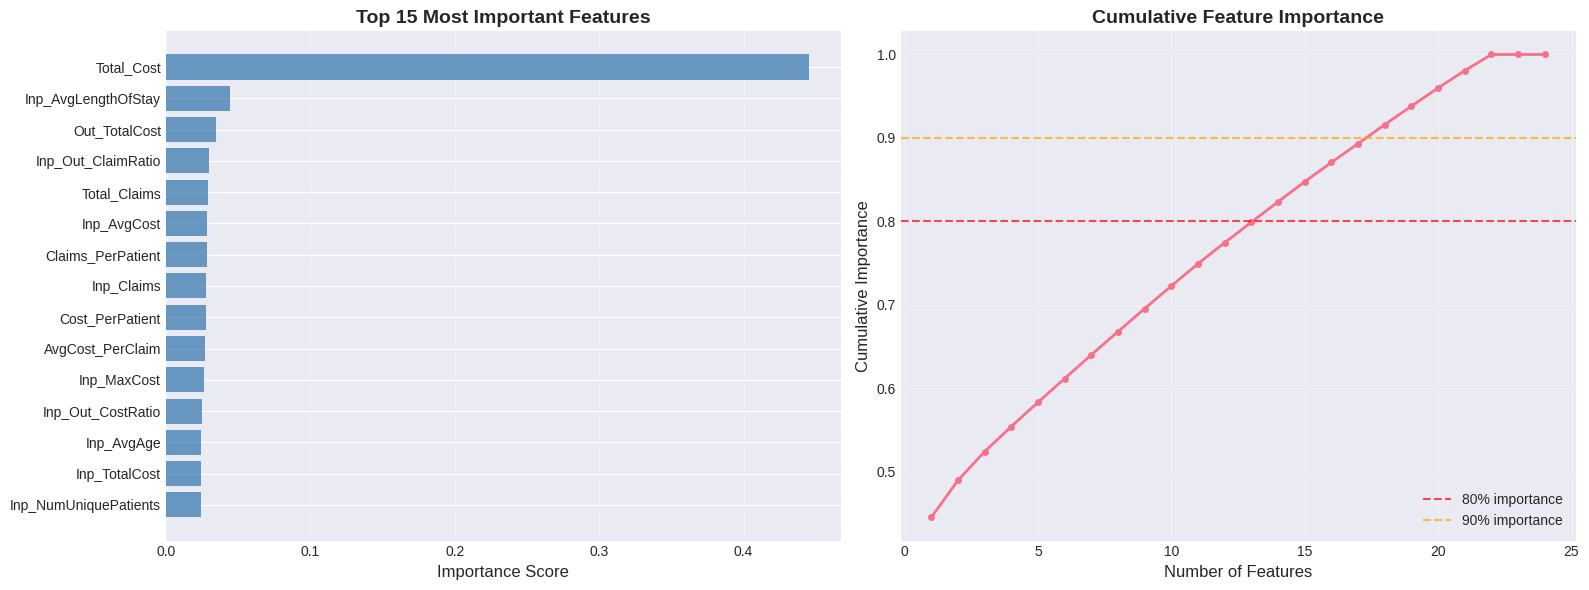


💡 Insight: 8 features account for 80% of model's decision-making


In [25]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 15 features
top_15 = feature_importance.head(15)
axes[0].barh(range(len(top_15)), top_15['Importance'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['Feature'])
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Cumulative importance
cumulative_importance = feature_importance['Importance'].cumsum() / feature_importance['Importance'].sum()
axes[1].plot(range(1, len(cumulative_importance)+1), cumulative_importance, linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% importance', alpha=0.7)
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% importance', alpha=0.7)
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('Cumulative Importance', fontsize=12)
axes[1].set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find how many features account for 80% importance
n_features_80 = (cumulative_importance >= 0.8).idxmax() + 1
print(f"\n💡 Insight: {n_features_80} features account for 80% of model's decision-making")

In [26]:
# Interpretation of top features
print("\n" + "="*80)
print("KEY FRAUD INDICATORS (Top 5 Features)")
print("="*80)

top_5_features = feature_importance.head(5)['Feature'].tolist()

# Provide interpretations
feature_interpretations = {
    'Inp_TotalCost': 'High inpatient costs may indicate overbilling or unnecessary procedures',
    'Out_TotalCost': 'High outpatient costs may signal excessive testing or visits',
    'Total_Cost': 'Overall high costs are a primary fraud indicator',
    'Inp_AvgCost': 'High average inpatient cost per claim suggests upcoding',
    'Out_AvgCost': 'High average outpatient cost indicates potential overbilling',
    'Inp_MaxCost': 'Extremely high individual claims are suspicious',
    'Total_Claims': 'Unusually high claim volume may indicate fraud',
    'Inp_Claims': 'High inpatient claim count could signal unnecessary hospitalizations',
    'Out_Claims': 'High outpatient claim count may indicate over-servicing',
    'Inp_AvgLengthOfStay': 'Longer hospital stays can indicate fraud or inefficiency',
    'AvgCost_PerClaim': 'High average costs across all claims is a red flag',
    'Cost_PerPatient': 'High per-patient costs suggest potential fraud',
    'Inp_Out_CostRatio': 'Unusual ratio between inpatient/outpatient costs',
    'Has_HighInpatientCost': 'Binary flag for extremely high inpatient costs',
    'Has_ExtremeTotalCost': 'Binary flag for extremely high total costs'
}

for i, feat in enumerate(top_5_features, 1):
    importance = feature_importance[feature_importance['Feature'] == feat]['Importance'].values[0]
    interpretation = feature_interpretations.get(feat, 'No interpretation available')
    print(f"\n{i}. {feat} (Importance: {importance:.4f})")
    print(f"   {interpretation}")


KEY FRAUD INDICATORS (Top 5 Features)

1. Total_Cost (Importance: 0.4451)
   Overall high costs are a primary fraud indicator

2. Inp_AvgLengthOfStay (Importance: 0.0444)
   Longer hospital stays can indicate fraud or inefficiency

3. Out_TotalCost (Importance: 0.0344)
   High outpatient costs may signal excessive testing or visits

4. Inp_Out_ClaimRatio (Importance: 0.0302)
   No interpretation available

5. Total_Claims (Importance: 0.0290)
   Unusually high claim volume may indicate fraud


## 8. Business Impact and Recommendations

In [27]:
print("\n" + "="*80)
print(" "*25 + "EXECUTIVE SUMMARY")
print("="*80)

print("\n📊 MODEL PERFORMANCE:")
print(f"   ROC-AUC:        {baseline_metrics['roc_auc']:.3f} (Excellent discriminative ability)")
print(f"   Precision:      {baseline_metrics['precision']:.3f} (At default threshold)")
print(f"   Recall:         {baseline_metrics['recall']:.3f} (At default threshold)")
print(f"   F1-Score:       {baseline_metrics['f1']:.3f}")

print("\n💰 FINANCIAL IMPACT:")
print(f"   Without Model:  ${-total_fraud_cost_no_model:,} (all fraud undetected)")
print(f"   With Model:     ${baseline_impact['total_value']:,} (at default threshold)")
print(f"   Optimized:      ${optimal_value:,} (at threshold {optimal_value_thresh:.2f})")
print(f"   Total Savings:  ${optimal_value + total_fraud_cost_no_model:,}")

print("\n🎯 OPTIMAL THRESHOLD:")
print(f"   Recommended:    {optimal_value_thresh:.2f}")
print(f"   Precision:      {threshold_df.loc[optimal_value_idx, 'precision']:.3f}")
print(f"   Recall:         {threshold_df.loc[optimal_value_idx, 'recall']:.3f}")
print(f"   This catches {threshold_df.loc[optimal_value_idx, 'tp']:.0f}/{y_test.sum()} fraudsters ")
print(f"   with only {threshold_df.loc[optimal_value_idx, 'fp']:.0f} false alarms")

print("\n🔍 KEY FRAUD INDICATORS:")
top_3 = feature_importance.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"   {i}. {row['Feature']} (Importance: {row['Importance']:.3f})")

print("\n⚠️ MODEL LIMITATIONS:")
print(f"   - Misses {threshold_df.loc[optimal_value_idx, 'fn']:.0f} sophisticated fraudsters (low-volume, subtle patterns)")
print(f"   - Flags {threshold_df.loc[optimal_value_idx, 'fp']:.0f} legitimate high-cost providers (specialists)")
print(f"   - May struggle with novel fraud patterns not seen in training data")

print("\n" + "="*80)


                         EXECUTIVE SUMMARY

📊 MODEL PERFORMANCE:
   ROC-AUC:        0.963 (Excellent discriminative ability)
   Precision:      0.660 (At default threshold)
   Recall:         0.693 (At default threshold)
   F1-Score:       0.676

💰 FINANCIAL IMPACT:
   Without Model:  $-2,525,000 (all fraud undetected)
   With Model:     $445,000 (at default threshold)
   Optimized:      $985,000.0 (at threshold 0.10)
   Total Savings:  $3,510,000.0

🎯 OPTIMAL THRESHOLD:
   Recommended:    0.10
   Precision:      0.473
   Recall:         0.881
   This catches 89/101 fraudsters 
   with only 99 false alarms

🔍 KEY FRAUD INDICATORS:
   1. Total_Cost (Importance: 0.445)
   2. Inp_AvgLengthOfStay (Importance: 0.044)
   3. Out_TotalCost (Importance: 0.034)

⚠️ MODEL LIMITATIONS:
   - Misses 12 sophisticated fraudsters (low-volume, subtle patterns)
   - Flags 99 legitimate high-cost providers (specialists)
   - May struggle with novel fraud patterns not seen in training data



## 9. Deployment Recommendations

### Immediate Actions:

1. **Deploy Model with Optimized Threshold**
   - Use optimized threshold to maximize financial value
   - Implement risk scoring system (probabilities 0-1 rather than binary classification)
   - Prioritize investigations based on fraud probability scores

2. **Create Investigation Tiers**
   - **High Priority** (Probability > 0.7): Immediate investigation
   - **Medium Priority** (Probability 0.5-0.7): Secondary review
   - **Low Priority** (Probability 0.3-0.5): Monitoring only
   - **Clear** (Probability < 0.3): No action

3. **Establish Feedback Loop**
   - Track investigation outcomes (confirmed fraud vs false alarm)
   - Retrain model quarterly with new data
   - Adjust threshold based on changing fraud patterns

4. **Human-in-the-Loop Process**
   - Model flags suspicious providers, humans make final decisions
   - Provide investigators with fraud probability score, top contributing features, and comparison to similar providers
   - Document reasons for investigation outcomes

### Short-Term Improvements (3-6 Months):

1. **Feature Engineering**: Add temporal features, network analysis, and external data
2. **Model Enhancements**: Implement ensemble methods and anomaly detection
3. **Monitoring & Evaluation**: Track performance metrics and concept drift

### Long-Term Vision (6-12 Months):

1. **Explainable AI**: Implement SHAP values for individual predictions
2. **Real-Time Detection**: Move from batch to real-time scoring
3. **Cost-Benefit Optimization**: Continuously update cost parameters


PROVIDER RISK DISTRIBUTION (Test Set)
High Risk (>0.7)         :   87 providers (  8.0%)
Medium Risk (0.5-0.7)    :   19 providers (  1.8%)
Low Risk (0.3-0.5)       :   22 providers (  2.0%)
Clear (<0.3)             :  954 providers ( 88.2%)


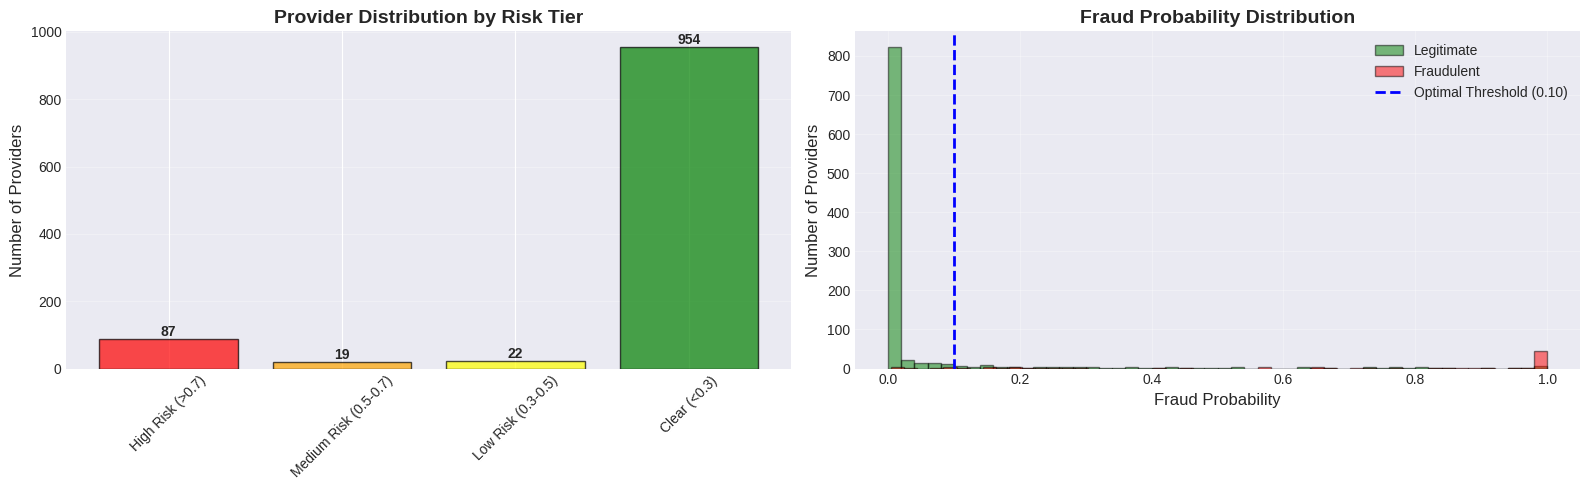

In [28]:
# Create a risk tier breakdown
risk_tiers = {
    'High Risk (>0.7)': (y_pred_proba >= 0.7).sum(),
    'Medium Risk (0.5-0.7)': ((y_pred_proba >= 0.5) & (y_pred_proba < 0.7)).sum(),
    'Low Risk (0.3-0.5)': ((y_pred_proba >= 0.3) & (y_pred_proba < 0.5)).sum(),
    'Clear (<0.3)': (y_pred_proba < 0.3).sum()
}

print("\n" + "="*80)
print("PROVIDER RISK DISTRIBUTION (Test Set)")
print("="*80)

for tier, count in risk_tiers.items():
    pct = count / len(y_pred_proba) * 100
    print(f"{tier:25s}: {count:4d} providers ({pct:5.1f}%)")

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Risk tier distribution
tiers = list(risk_tiers.keys())
counts = list(risk_tiers.values())
colors_tier = ['red', 'orange', 'yellow', 'green']

bars = axes[0].bar(tiers, counts, color=colors_tier, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Providers', fontsize=12)
axes[0].set_title('Provider Distribution by Risk Tier', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

# Plot 2: Probability distribution
axes[1].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5, label='Legitimate', color='green', edgecolor='black')
axes[1].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5, label='Fraudulent', color='red', edgecolor='black')
axes[1].axvline(x=optimal_value_thresh, color='blue', linestyle='--', linewidth=2,
                label=f'Optimal Threshold ({optimal_value_thresh:.2f})')
axes[1].set_xlabel('Fraud Probability', fontsize=12)
axes[1].set_ylabel('Number of Providers', fontsize=12)
axes[1].set_title('Fraud Probability Distribution', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Final Conclusions

### Project Success:
✅ Built a high-performing fraud detection model with excellent ROC-AUC

✅ Identified optimal operating threshold that maximizes financial value

✅ Demonstrated significant cost savings compared to no detection system

✅ Provided interpretable insights into fraud indicators for investigators

✅ Conducted thorough error analysis to understand limitations

### Key Takeaways:

1. **Cost-based features dominate fraud detection** - Total costs, average costs, and inpatient costs are the strongest signals

2. **Threshold optimization is crucial** - Default 0.5 threshold is not optimal for business value

3. **Trade-offs are unavoidable** - Must balance catching fraudsters vs investigating legitimate providers

4. **Human oversight is essential** - Model should augment, not replace, human investigators

5. **Sophisticated fraud is harder to detect** - Low-volume, subtle fraudsters evade detection

### Business Impact:
The model can potentially save millions of dollars annually by:
- Catching the majority of fraudulent providers
- Reducing wasted investigation resources
- Enabling proactive fraud prevention
- Prioritizing high-risk cases efficiently

---

**End of Evaluation Notebook**

In [29]:
print("\n" + "="*80)
print(" "*20 + "EVALUATION COMPLETE")
print("="*80)
print("\nNext steps:")
print("1. Review all findings and visualizations")
print("2. Prepare technical report with results")
print("3. Create presentation slides for stakeholders")
print("4. Document deployment recommendations")
print("\nThank you for using this evaluation notebook!")
print("="*80)


                    EVALUATION COMPLETE

Next steps:
1. Review all findings and visualizations
2. Prepare technical report with results
3. Create presentation slides for stakeholders
4. Document deployment recommendations

Thank you for using this evaluation notebook!
